In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import requests
from pathlib import Path

In [28]:
url = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"

data_dir = Path("/home/jovyan/CLMT5045-FinalProject/data")
data_dir.mkdir(exist_ok=True)

zip_path = data_dir / "beijing_air_quality.zip"

if not zip_path.exists():
    response = requests.get(url)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

with zipfile.ZipFile(zip_path,"r") as zip_ref:
    zip_ref.extractall(data_dir)

In [29]:
zip_path = data_dir / "PRSA2017_Data_20130301-20170228.zip"
air_data_dir = data_dir / "PRSA_Data_20130301-20170228"

if not air_data_dir.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

csv_files = list(air_data_dir.glob("*.csv"))

print(len(csv_files))
csv_files

12


[PosixPath('/home/jovyan/CLMT5045-FinalProject/data/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv'),
 PosixPath('/home/jovyan/CLMT5045-FinalProject/data/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv'),
 PosixPath('/home/jovyan/CLMT5045-FinalProject/data/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv'),
 PosixPath('/home/jovyan/CLMT5045-FinalProject/data/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv'),
 PosixPath('/home/jovyan/CLMT5045-FinalProject/data/PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv'),
 PosixPath('/home/jovyan/CLMT5045-FinalProject/data/PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv'),
 PosixPath('/home/jovyan/CLMT5045-FinalProject/data/PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv'),
 PosixPath('/home/jovyan/CLMT5045-FinalProject/data/PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv'),
 Po

In [30]:
# Load and combine all station-level CSV files into one dataframe
csv_files = list(air_data_dir.glob("*.csv"))


dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

air = pd.concat(dfs, ignore_index=True)

air.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [32]:
# air["station"].unique()

In [33]:
# Create a datetime column from year, month, day, and hour
air["datetime"] = pd.to_datetime(
    air[["year", "month", "day", "hour"]]
)

# Set datetime as the dataframe index for time-series analysis
air = air.set_index("datetime")

air.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
2013-03-01 01:00:00,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2013-03-01 02:00:00,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
2013-03-01 03:00:00,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
2013-03-01 04:00:00,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [34]:
#air.index.min(), air.index.max()

In [35]:
#air["station"].nunique()


In [36]:
#air["station"].value_counts()

In [37]:
# Define the pollutants used in this notebook
pollutants = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]

# Aggregate hourly data into citywide monthly means
monthly = air[pollutants].resample("M").mean()

monthly.head()

/tmp/ipykernel_53/3346564102.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = air[pollutants].resample("M").mean()


,PM2.5,PM10,SO2,NO2,CO,O3
datetime,,,,,,
2013-03-31,104.888301,128.975504,38.515429,67.902013,1457.180706,56.578226
2013-04-30,62.139109,95.901222,20.738534,46.297060,903.044982,61.761871
2013-05-31,81.846225,131.470677,25.487758,50.573004,999.388040,85.767320
2013-06-30,102.444121,115.945019,13.768520,48.221292,1420.356566,75.204760
2013-07-31,67.909378,76.460205,7.434409,39.453048,941.546701,79.771796


In [39]:
#monthly.shape

Figure 1: Monthly pollutant trends with rolling mean

To examine the raw trend in Beijing's air quality, first, I aggregated all the 12 monitoring stations's data from hourly data to monthly means. This aggregation can reduce hourly data noise and preserve the basic data structure at the same time. Then, I added a 12-month centered rolling mean to smooth seasonal fluctuations and to better compare the long-term pollutant trends among PM2.5, PM10, SO2 and NO2

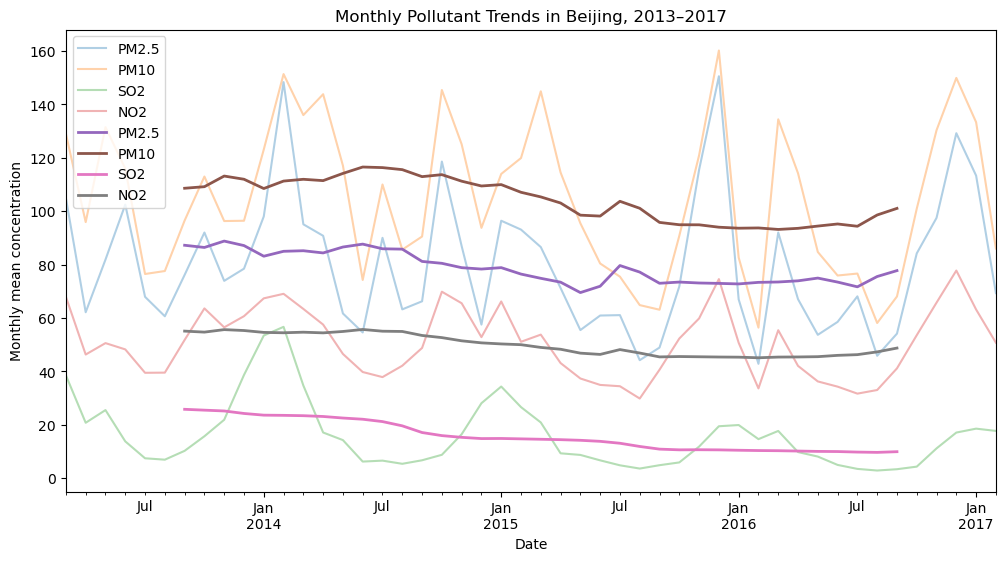

In [40]:
selected_pollutants = ["PM2.5", "PM10", "SO2", "NO2"]

# Calculate a 12-month centered rolling mean to smooth short-term seasonal fluctuations
rolling = monthly[selected_pollutants].rolling(
    window=12,
    center=True
).mean()

# Plot raw monthly means as faint lines
ax = monthly[selected_pollutants].plot(
    figsize=(12, 6),
    alpha=0.35
)

# Overlay the smoothed rolling mean as stronger lines
rolling.plot(
    ax=ax,
    linewidth=2
)

plt.title("Monthly Pollutant Trends in Beijing, 2013–2017")
plt.xlabel("Date")
plt.ylabel("Monthly mean concentration")
plt.legend()
plt.show()

The monthly series shows strong short-term and seasonal fluctuations. And the rolling mean helps us to clearly see whether pollutants declined during the policy window.

Figure 2: Deseasonalized anomaly trend

Raw monthly averages can be misleading, as air pollution has strong seasonal patterns. For example, winter months tend to have higher PM2.5 levels than summer months. To minimize this seasonality, I compute a monthly climatology for each pollutant and subtract it from the observed monthly mean. This creates a deseasonalized anomaly, with positive values indicating dirtier-than-normal months for that particular month of the year, and negative values indicating cleaner-than-normal months.

In [41]:
monthly_copy = monthly.copy()
# Add the month from the datetime index
monthly_copy["month"] = monthly_copy.index.month

# Calculate the average value for each month
monthly_climatology = monthly_copy.groupby("month")[pollutants].transform("mean")

# Subtract the monthly climatology from the observed monthly mean
anomaly = monthly[pollutants] - monthly_climatology
anomaly.head()

,PM2.5,PM10,SO2,NO2,CO,O3
datetime,,,,,,
2013-03-31,10.261250,-7.083667,10.581937,7.793722,145.532017,5.546285
2013-04-30,-10.647342,-21.190136,6.518270,-0.939145,61.771170,-8.407023
2013-05-31,18.683360,24.297036,11.362966,7.916237,196.503151,-6.202266
2013-06-30,33.334012,29.331835,5.873142,8.932890,416.676118,-19.514098
2013-07-31,-3.856345,-8.173156,1.872735,3.610780,46.797964,-15.250925


In [42]:
selected_pollitants = ["PM2.5", "PM10", "SO2", "NO2"]

# Smooth the deseasonalized anomalies using a 6-month centered rolling mean
anomaly_smooth = anomaly[selected_pollutants].rolling(
    window = 6,
    center = True
).mean()

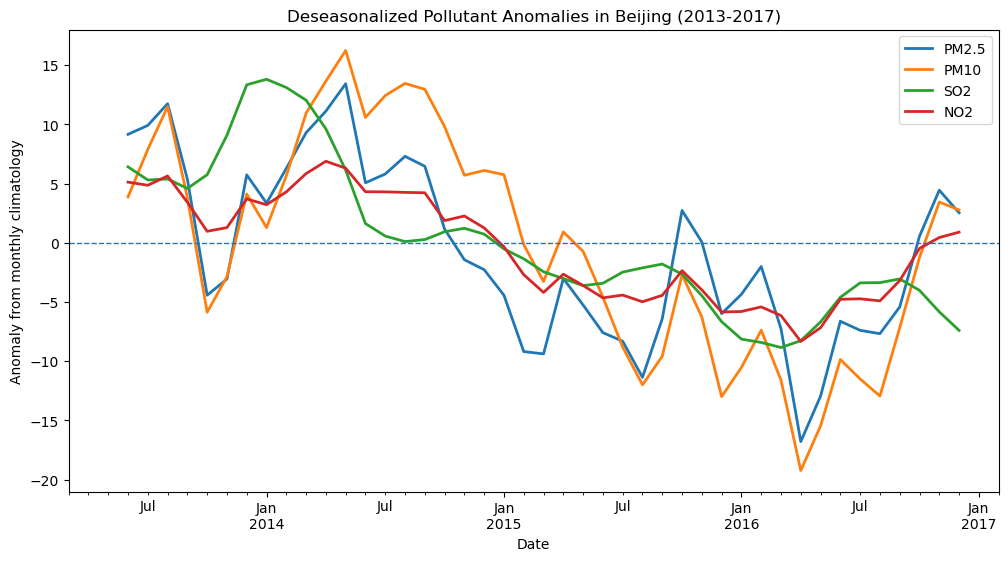

In [43]:
anomaly_smooth.plot(figsize = (12,6), linewidth = 2)

# Add a zero line to show the normal monthly level
plt.axhline(0, linestyle = "--", linewidth = 1)

plt.title("Deseasonalized Pollutant Anomalies in Beijing (2013-2017)")
plt.xlabel("Date")
plt.ylabel("Anomaly from monthly climatology")
plt.legend()
plt.show()

The deseasonalized anomaly plot shows a shift from mostly positive anomalies in the earlier part of the record to mostly negative anomalies during 2015–2016. This suggests that pollutant levels became lower than their typical monthly values later, even after accounting for the regular seasonal cycle. The pattern is especially visible for PM2.5, PM10, SO2, and NO2, supporting the interpretation that air quality improved beyond normal seasonal variation.

Figure 3: Indexed annual comparison

The raw concentrations of different pollutants are not directly comparable because they have different units and value ranges. To compare relative changes across pollutants, I normalize each pollutant’s annual mean to the 2014 value. I set 2014 equal to 100 for every pollutant, so values below 100 indicate a decline relative to the 2014 baseline. I use 2014–2016 because they are the complete years in the dataset.

In [44]:
# Aggregate hourly data into annual means
annual = air[pollutants].resample("Y").mean()

# Change the index to year
annual.index = annual.index.year
annual

/tmp/ipykernel_53/372594229.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = air[pollutants].resample("Y").mean()


,PM2.5,PM10,SO2,NO2,CO,O3
datetime,,,,,,
2013,80.040536,102.823208,20.048420,52.534040,1203.131299,57.326222
2014,85.575700,116.126691,20.878454,54.781129,1256.904078,58.307991
2015,79.626788,103.613500,13.014975,48.191862,1257.823438,59.240321
2016,71.930151,94.615609,9.799084,46.395580,1138.790118,57.455946
2017,92.675992,111.117149,18.136980,57.331760,1599.710005,39.914663


In [45]:
# Use only complete years
annual_final = annual.loc[2014:2016]
annual_final

,PM2.5,PM10,SO2,NO2,CO,O3
datetime,,,,,,
2014,85.575700,116.126691,20.878454,54.781129,1256.904078,58.307991
2015,79.626788,103.613500,13.014975,48.191862,1257.823438,59.240321
2016,71.930151,94.615609,9.799084,46.395580,1138.790118,57.455946


In [46]:
# Normalize each pollutant to its 2014 value
indexed = annual_final / annual_final.loc[2014]*100
indexed 

,PM2.5,PM10,SO2,NO2,CO,O3
datetime,,,,,,
2014,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2015,93.048363,89.224535,62.336873,87.971649,100.073145,101.598976
2016,84.054411,81.476195,46.933953,84.692633,90.602786,98.538717


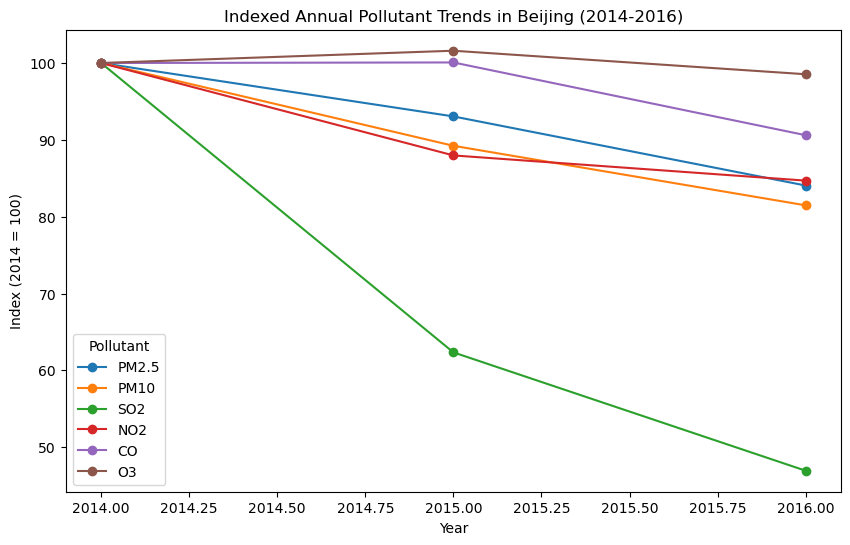

In [47]:
indexed.plot(marker="o",figsize=(10, 6))

plt.title("Indexed Annual Pollutant Trends in Beijing (2014-2016)")
plt.xlabel("Year")
plt.ylabel("Index (2014 = 100)")
plt.legend(title="Pollutant")
plt.show()

Figure 4: Per-pollutant percentage change

To summarize the indexed trends more directly, I calculate the percentage change in annual mean concentration from 2014 to 2016 for each pollutant. Negative values indicate that the pollutant declined relative to 2014, while positive values indicate an increase. This figure provides a simple quantitative comparison of which pollutant experienced the largest relative decrease.

In [48]:
# Calculate the percentage change from 2014 to 2016 for each pollutant
percent_change = (
    (annual_final.loc[2016] - annual_final.loc[2014]) / annual_final.loc[2014] * 100
)
percent_change

PM2.5   -15.945589
PM10    -18.523805
SO2     -53.066047
NO2     -15.307367
CO       -9.397214
O3       -1.461283
dtype: float64

In [49]:
# Sort pollutants from the largest decline to the smallest decline
percent_change_sorted = percent_change.sort_values()
percent_change_sorted

SO2     -53.066047
PM10    -18.523805
PM2.5   -15.945589
NO2     -15.307367
CO       -9.397214
O3       -1.461283
dtype: float64

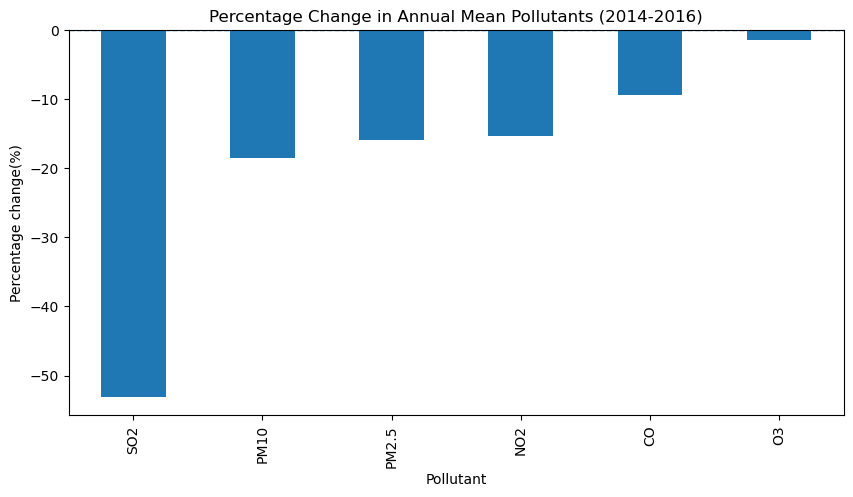

In [50]:
percent_change_sorted.plot(kind="bar", figsize=(10, 5))
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Percentage Change in Annual Mean Pollutants (2014-2016)")
plt.xlabel("Pollutant")
plt.ylabel("Percentage change(%)")
plt.show()

The indexed trend and percentage-change comparison show that SO2 had the clearest and largest relative decline from 2014 to 2016, falling by more than half. PM10, PM2.5, NO2, and CO also declined, but their decreases were smaller. While O3 changed very little. These results support the hypothesis that coal-linked pollutants, especially SO2, showed the strongest downward signal, while PM2.5 improvement was real but less dramatic.